# 2 - Interval Analysis

## Imports

In [170]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [171]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

In [172]:
metadata = g.load_metadata()

## In-Label Intervals

### Example: Subset

In [175]:


subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]


In [176]:
ILC = g.load_labels(subset)
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
identifier = ['artist', 'workTitle']
ILC = ILC.groupby(identifier, as_index=False).agg(list)

In [177]:
data = ia.create_data(ILC, identifier)

In [178]:
#ia.plot_interval_distribution(data, identifier)

- Next step: notes sounding simultaneously (consider duration !!!)
- Debug: look at two pieces in same key and two pieces in different keys to look at the interval and pitch class
- group plots by artist or key or year 

### By artist

In [181]:
grouped_artists = metadata['artists'].value_counts()
subset_artists = grouped_artists.iloc[0:8].index
subset = metadata[metadata['artists'].isin(subset_artists)]
subset_artists

Index(['Frank Zappa', 'Bill Evans', 'Yohan Kim', 'Dexter Gordon',
       'Miles Davis', 'Chet Baker', 'Bob Mintzer', 'Paul Desmond'],
      dtype='object')

In [182]:
ILC = g.load_labels(subset)
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
identifier = ['artist']
ILC = ILC.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(ILC, identifier)

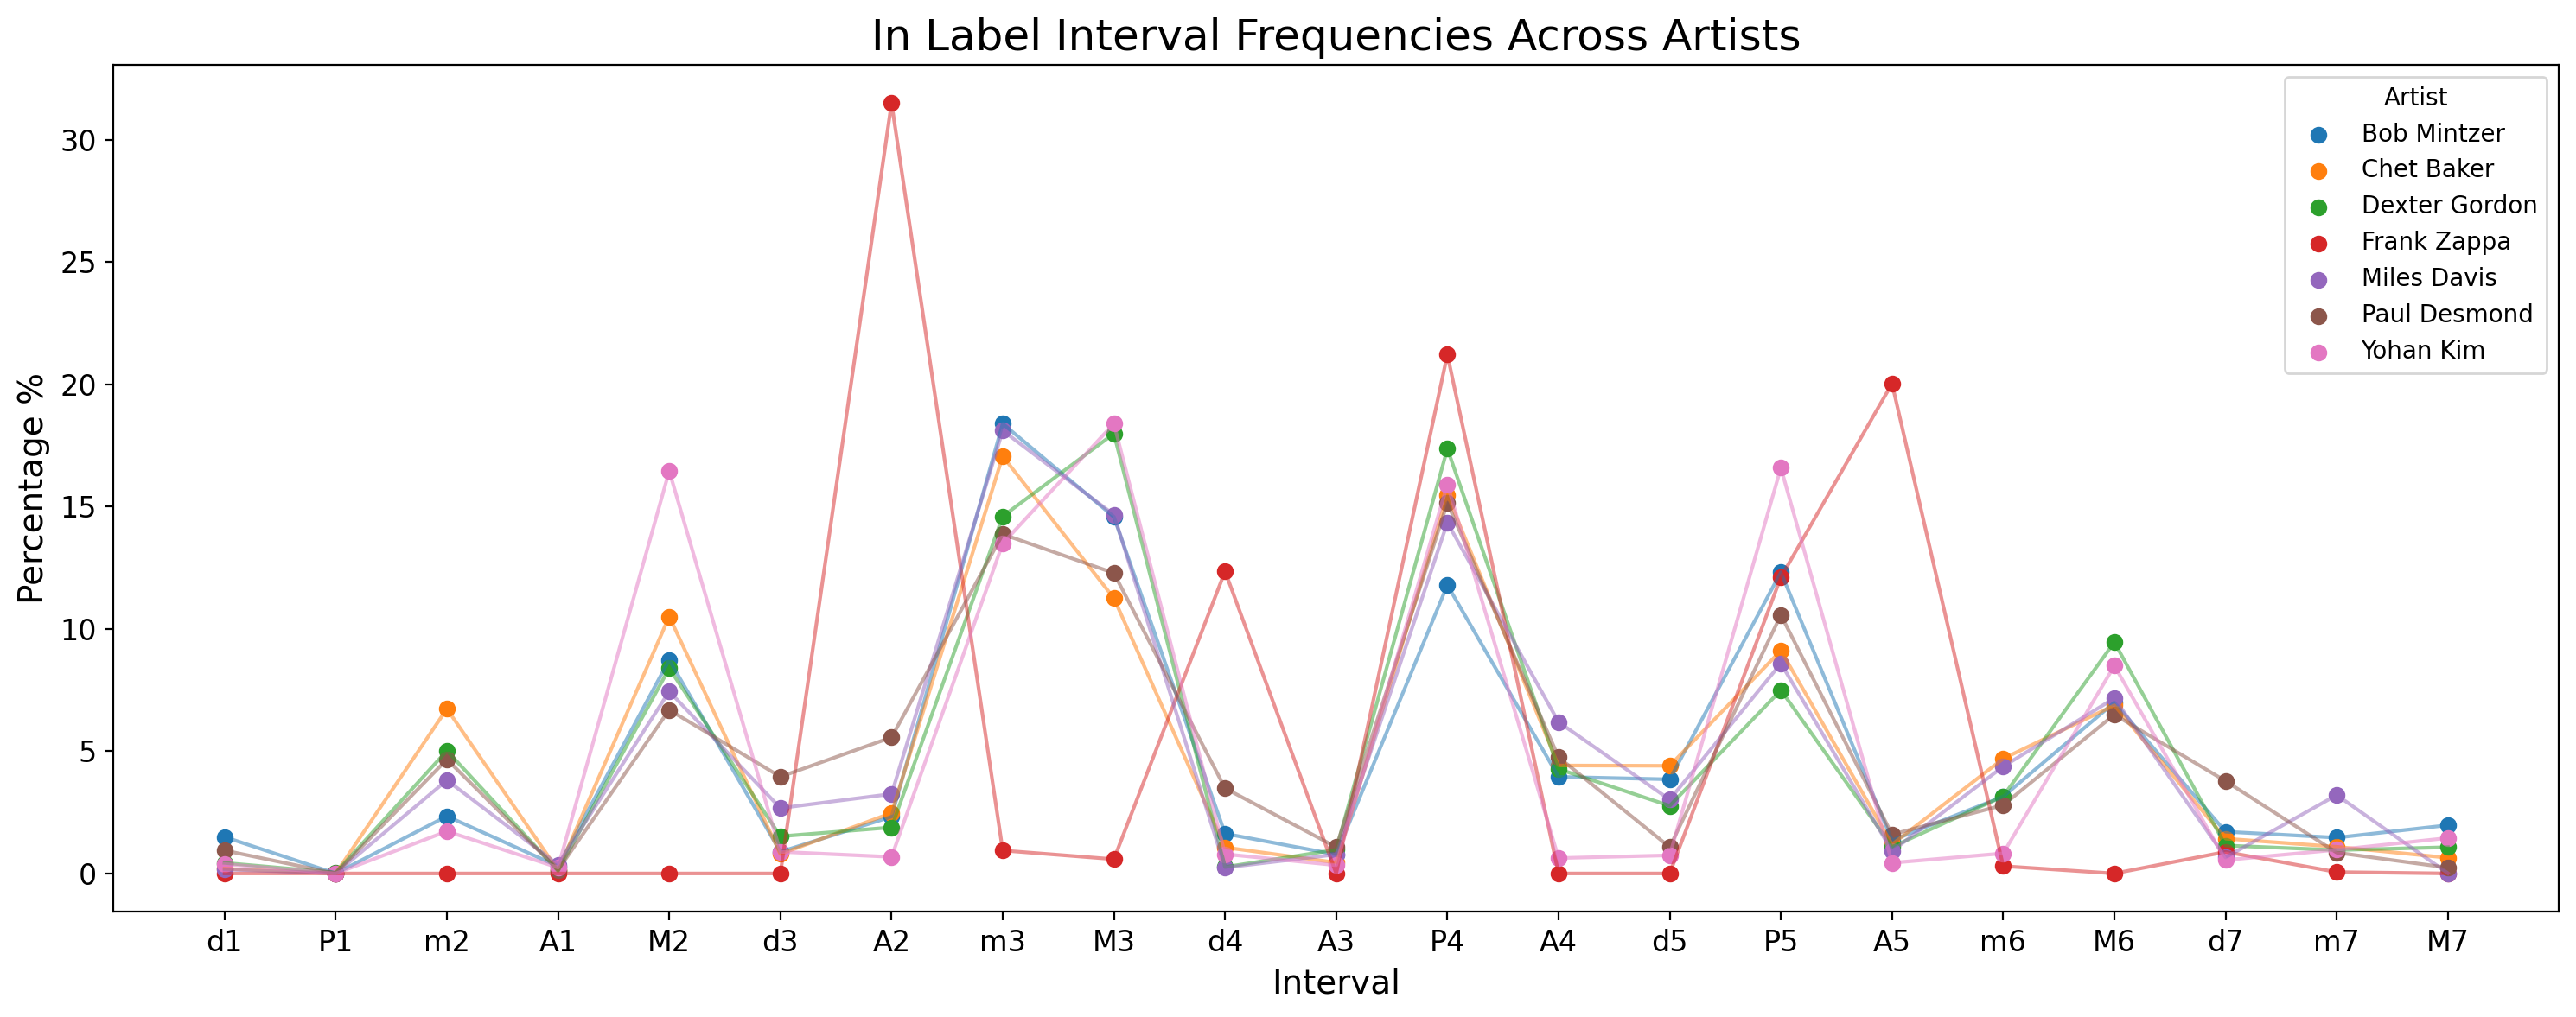

In [183]:
canonical_intervals = [
    'd1', 'P1', 'm2', 'A1', 'M2', 'd3', 'A2', 'm3', 'M3', 'd4', 'A3', 'P4', 'A4', 'd5',
    'P5', 'A5', 'm6', 'M6', 'd7', 'm7', 'M7'
]

interval_order = {
    'd1': -1,
    'P1': 0,
    'm2': 1, 'A1': 1,
    'M2': 2, 'd3': 2,
    'A2': 3, 'm3': 3,
    'M3': 4, 'd4': 4,
    'A3': 5 ,'P4': 5,
    'A4': 6, 'd5': 6,
    'P5': 7,
    'A5': 8, 'm6': 8,  
    'M6': 9, 'd7': 9,
    'm7': 10,
    'M7': 11,
}

baseline_df = pd.DataFrame({
    'interval_name': canonical_intervals,
    'percentage': 0.0
})

keys = list(data.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['tab10']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i))
    
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In Label Interval Frequencies Across Artists', fontsize=18)
ax.legend(title='Artist')


plt.tight_layout()
plt.savefig(f"../Results/Artist_Interval_InLabel")
plt.show()

In [184]:
#ia.plot_interval_distribution(data, identifier)

### By year

In [186]:
grouped_year = metadata['recording_year'].value_counts()
subset_year = grouped_year.iloc[0:8].index
subset = metadata[metadata['recording_year'].isin(subset_year)]

In [187]:
ILC = g.load_labels(subset)
ILC['interval'] = ILC['label'].apply(ia.label_to_intervals)
identifier = ['recording_year']
ILC = ILC.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(ILC, identifier)


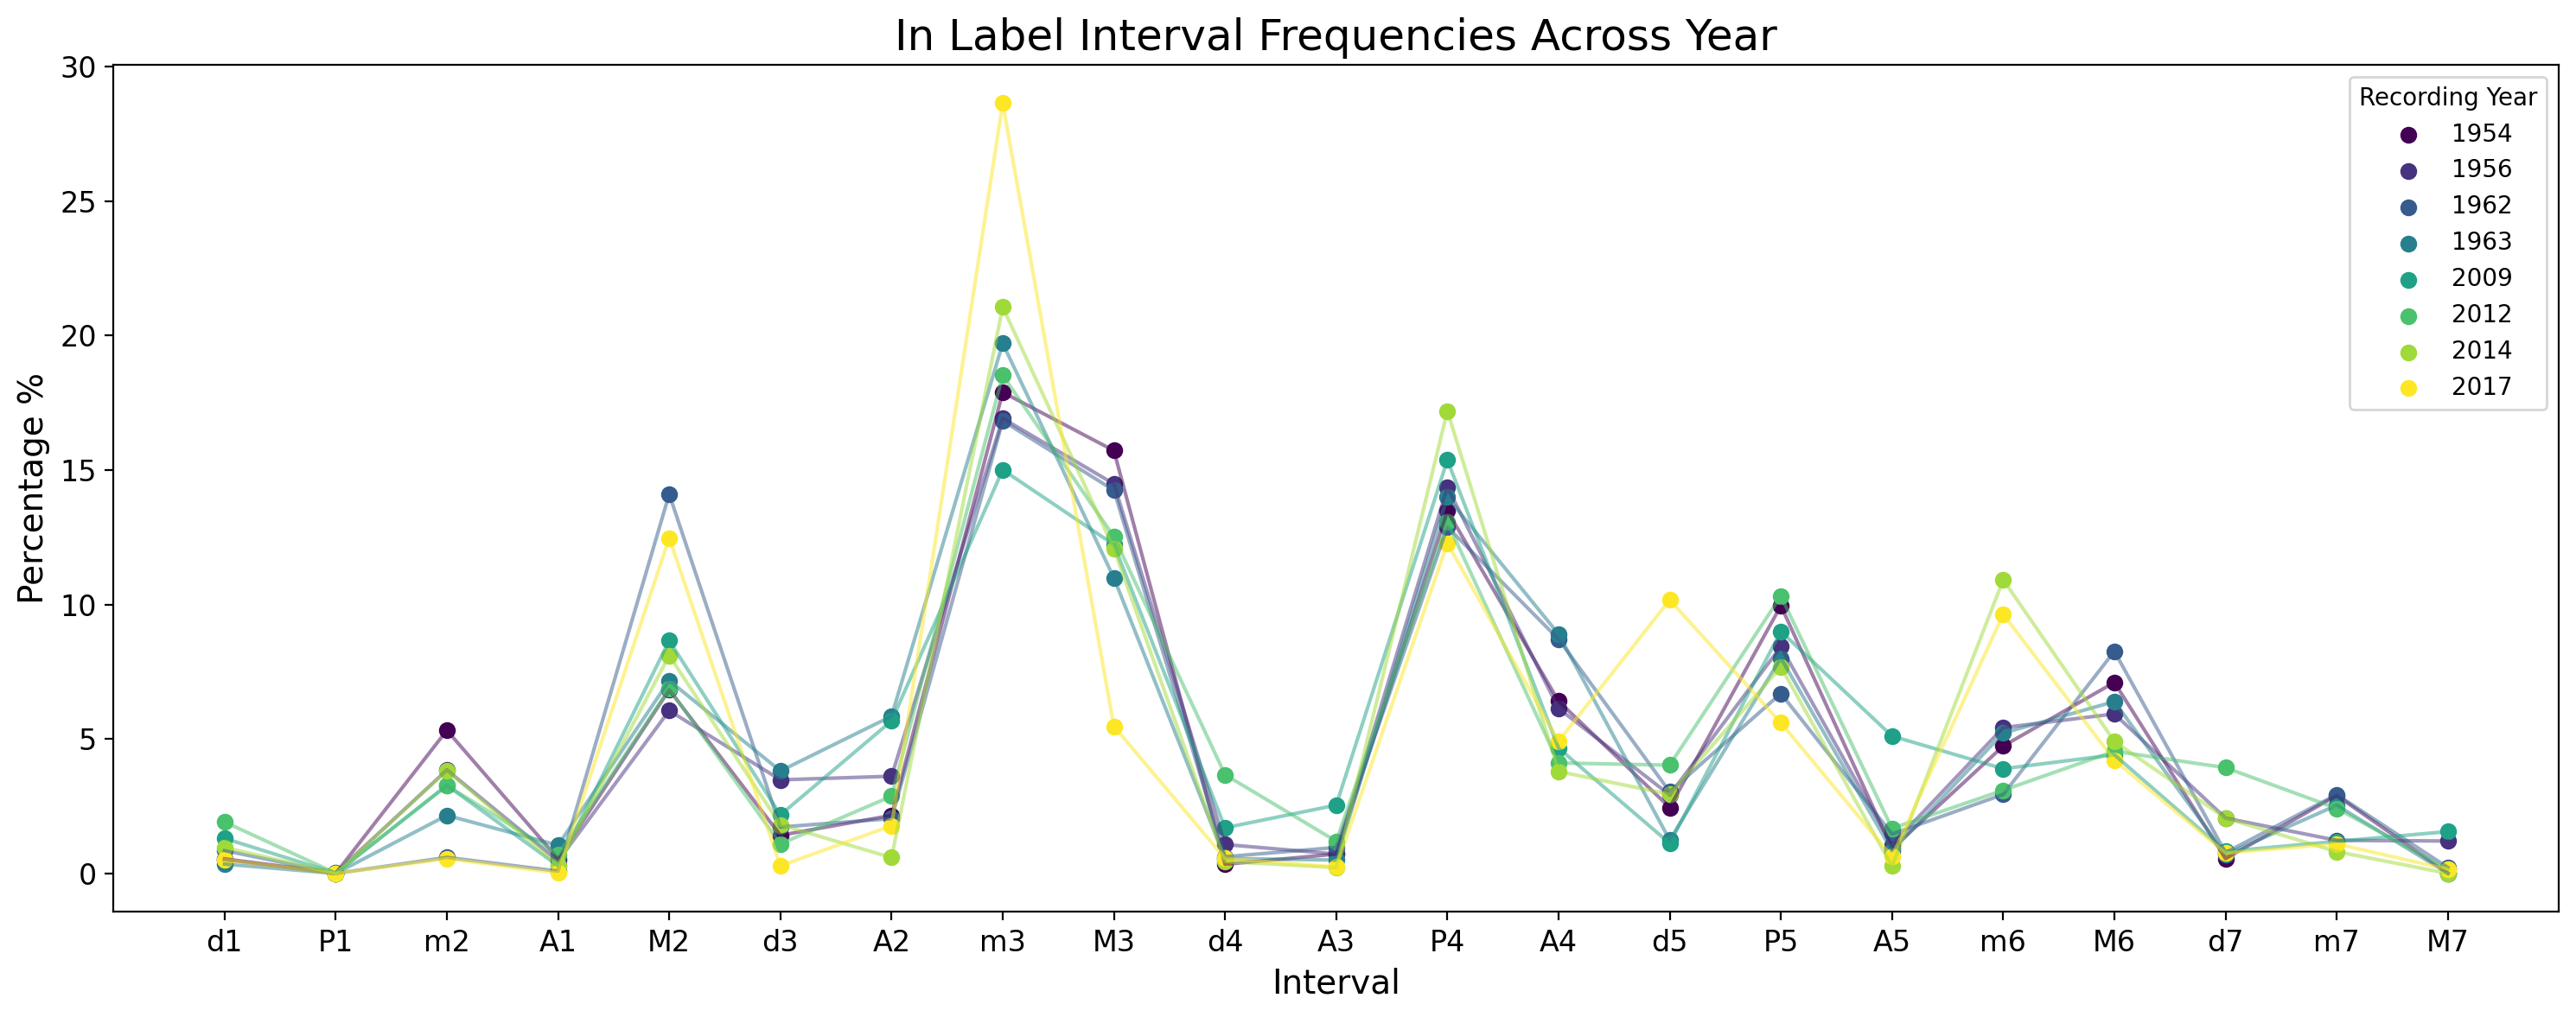

In [188]:
canonical_intervals = [
    'd1', 'P1', 'm2', 'A1', 'M2', 'd3', 'A2', 'm3', 'M3', 'd4', 'A3', 'P4', 'A4', 'd5',
    'P5', 'A5', 'm6', 'M6', 'd7', 'm7', 'M7'
]

interval_order = {
    'd1': -1,
    'P1': 0,
    'm2': 1, 'A1': 1,
    'M2': 2, 'd3': 2,
    'A2': 3, 'm3': 3,
    'M3': 4, 'd4': 4,
    'A3': 5 ,'P4': 5,
    'A4': 6, 'd5': 6,
    'P5': 7,
    'A5': 8, 'm6': 8,  
    'M6': 9, 'd7': 9,
    'm7': 10,
    'M7': 11,
}

baseline_df = pd.DataFrame({
    'interval_name': canonical_intervals,
    'percentage': 0.0
})

keys = list(data.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In Label Interval Frequencies Across Year', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_InLabel")
plt.show()

## Heard Interval Analysis

### Example: Subset

In [191]:
metadata = g.load_metadata()
subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]

harmonies_subset = g.load_harmonies(subset)


In [192]:
identifier = ['artist', 'workTitle']
harmonies_subset = harmonies_subset.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(harmonies_subset, identifier)

In [193]:
#ia.plot_interval_distribution(data, identifier)

## By Artist

In [195]:
grouped_artists = metadata['artists'].value_counts()
subset_artists = grouped_artists.iloc[0:8].index
subset = metadata[metadata['artists'].isin(subset_artists)]

In [196]:
subset = g.load_harmonies(subset)
identifier = ['artist']
subset = subset.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(subset, identifier)


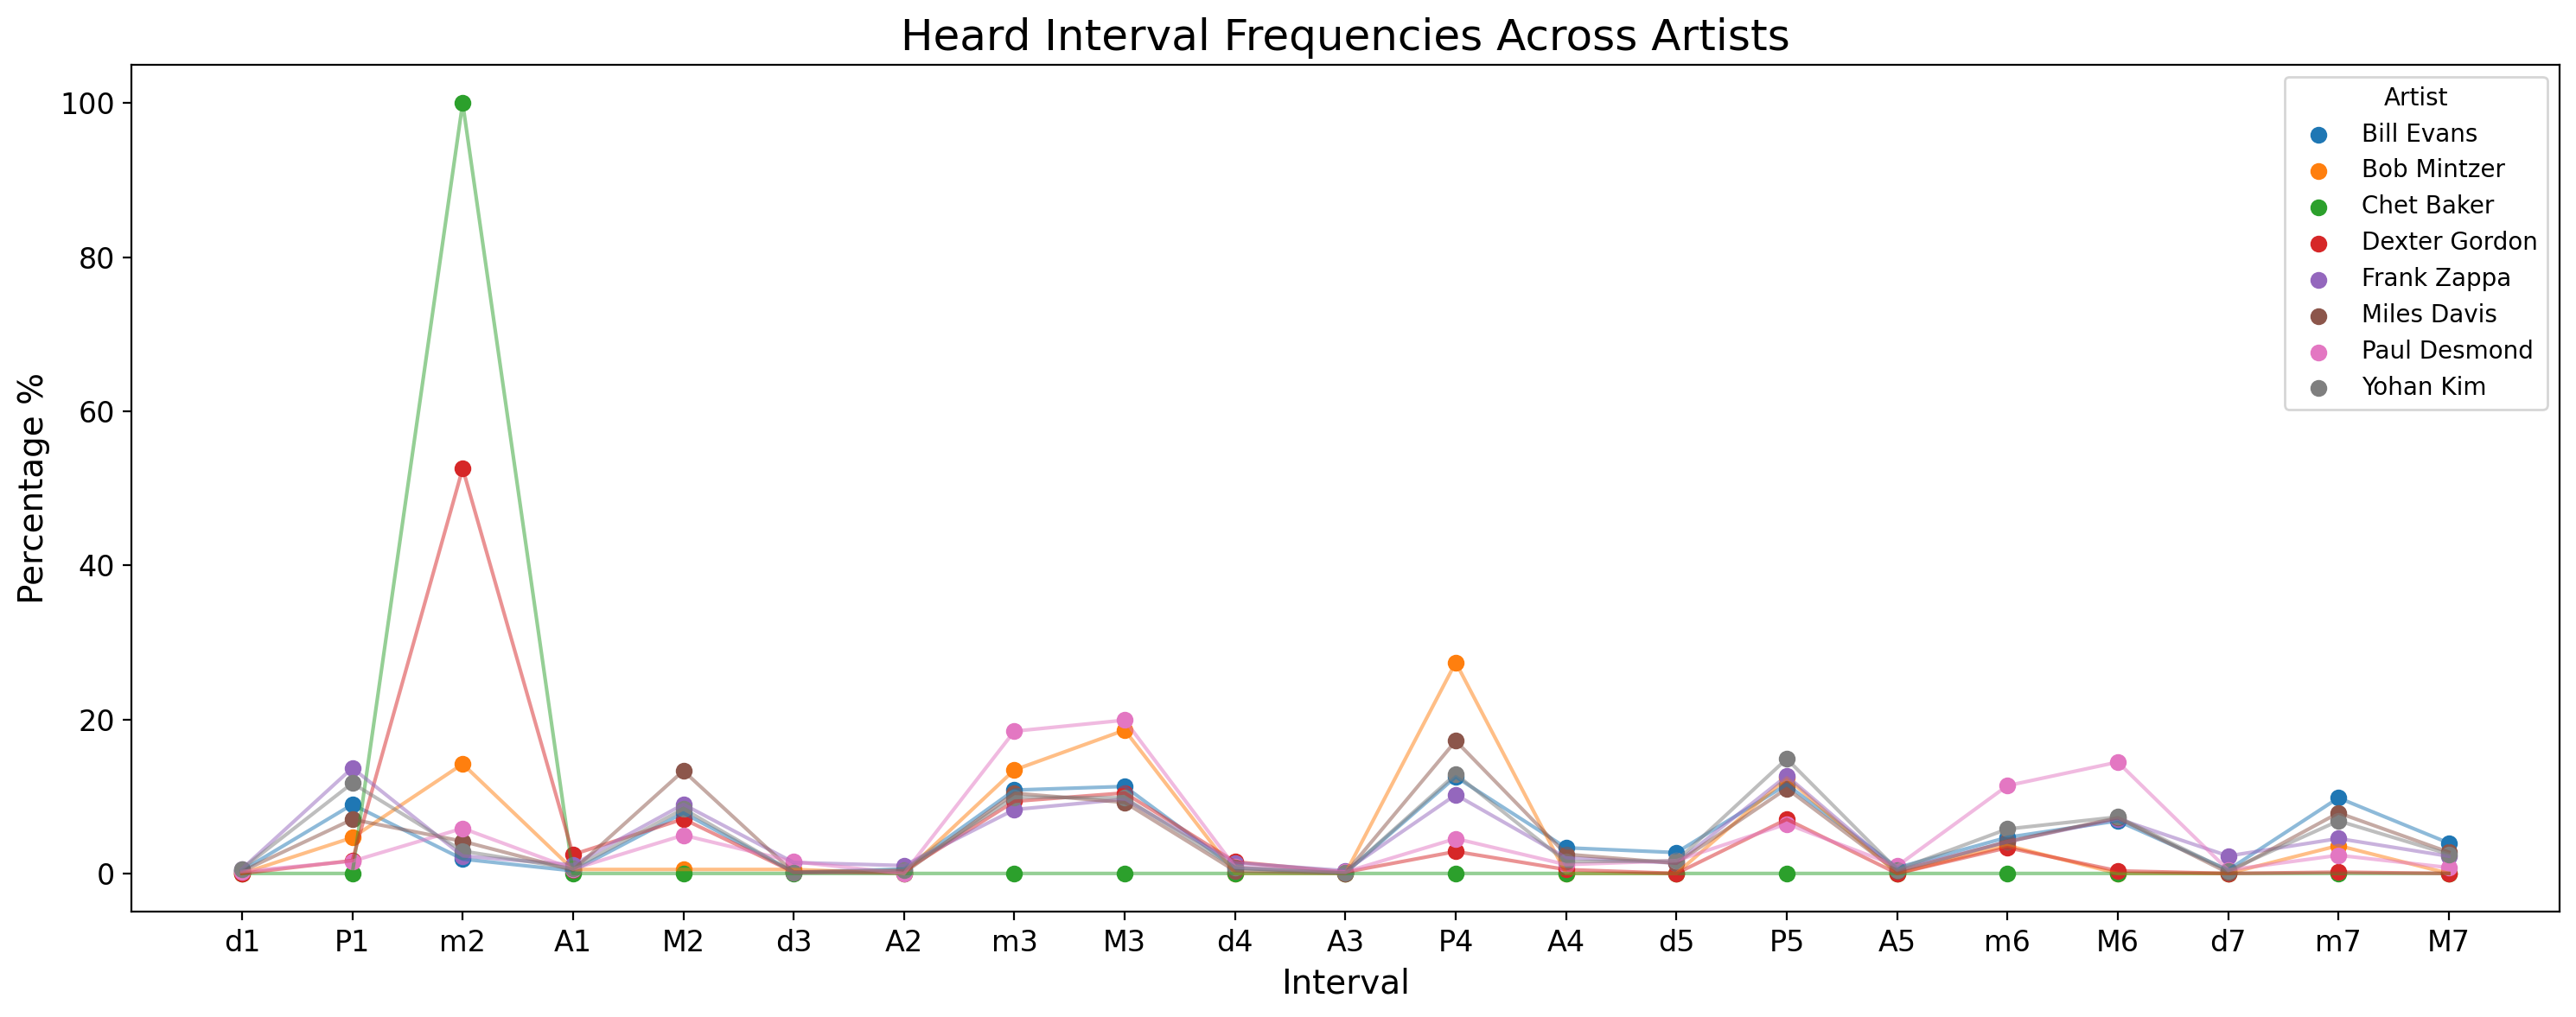

In [197]:
#ia.plot_interval_distribution(data, identifier, "0623_jazz_artist_interval")
canonical_intervals = [
    'd1', 'P1', 'm2', 'A1', 'M2', 'd3', 'A2', 'm3', 'M3', 'd4', 'A3', 'P4', 'A4', 'd5',
    'P5', 'A5', 'm6', 'M6', 'd7', 'm7', 'M7'
]

interval_order = {
    'd1': -1,
    'P1': 0,
    'm2': 1, 'A1': 1,
    'M2': 2, 'd3': 2,
    'A2': 3, 'm3': 3,
    'M3': 4, 'd4': 4,
    'A3': 5 ,'P4': 5,
    'A4': 6, 'd5': 6,
    'P5': 7,
    'A5': 8, 'm6': 8,  
    'M6': 9, 'd7': 9,
    'm7': 10,
    'M7': 11,
}

baseline_df = pd.DataFrame({
    'interval_name': canonical_intervals,
    'percentage': 0.0
})

keys = list(data.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['tab10']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i))
    
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Artists', fontsize=18)
ax.legend(title='Artist')


plt.tight_layout()
plt.savefig(f"../Results/Artist_Interval_Heard")
plt.show()

Is there a way to bootstrap the data??

## By Year

In [200]:
grouped_year = metadata['recording_year'].value_counts()
subset_year = grouped_year.iloc[0:8]
subset_year

1963    24
1956    20
2017    15
1954    11
1962    11
2014     8
2012     8
2009     8
Name: recording_year, dtype: int64

In [201]:
subset_year = subset_year.copy().index
subset = metadata[metadata['recording_year'].isin(subset_year)]
subset.head(5)

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
2,by_Alexander_Booker,Vulfpeck-Fugue_State,71,71,1: 0,1: 4/4,13,NaN,"Woody Goss, Jack Stratton",Fugue State,...,NaN,NaN,NaN,NaN,NaN,NaN,"ep, g, b, dr",complete,Concert Key,1
6,by_Carles_Margarit,All Of Me - Lester Young (Bb),310,310,1: 2,1: 4/4,187,NaN,"Gerald Marks, Seymour Simons",All Of Me,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Bb,1
7,by_Carles_Margarit,All The Things You Are - Bob Mintzer (Concert ...,86,86,1: -2,1: 4/4,75,NaN,"Jerome David Kern, Oscar Hammerstein",All The Things You Are,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Concert Key,0
9,by_Carles_Margarit,All The Things You Are - Paul Desmond (Concert...,145,145,1: -3,1: 4/4,145,a,"Jerome David Kern, Oscar Hammerstein",All The Things You Are,...,NaN,NaN,NaN,NaN,NaN,NaN,as,solo,Concert Key,1
12,by_Carles_Margarit,Au Privave - Sonny Stitt (Concert Key),153,153,1: -1,1: 4/4,0,NaN,Charlie Parker,Au Privave,...,NaN,NaN,NaN,NaN,NaN,NaN,as,complete,Concert Key,1


In [202]:
subset = g.load_harmonies(subset)
identifier = ['recording_year']
subset = subset.groupby(identifier, as_index=False).agg(list)
data = ia.create_data(subset, identifier)

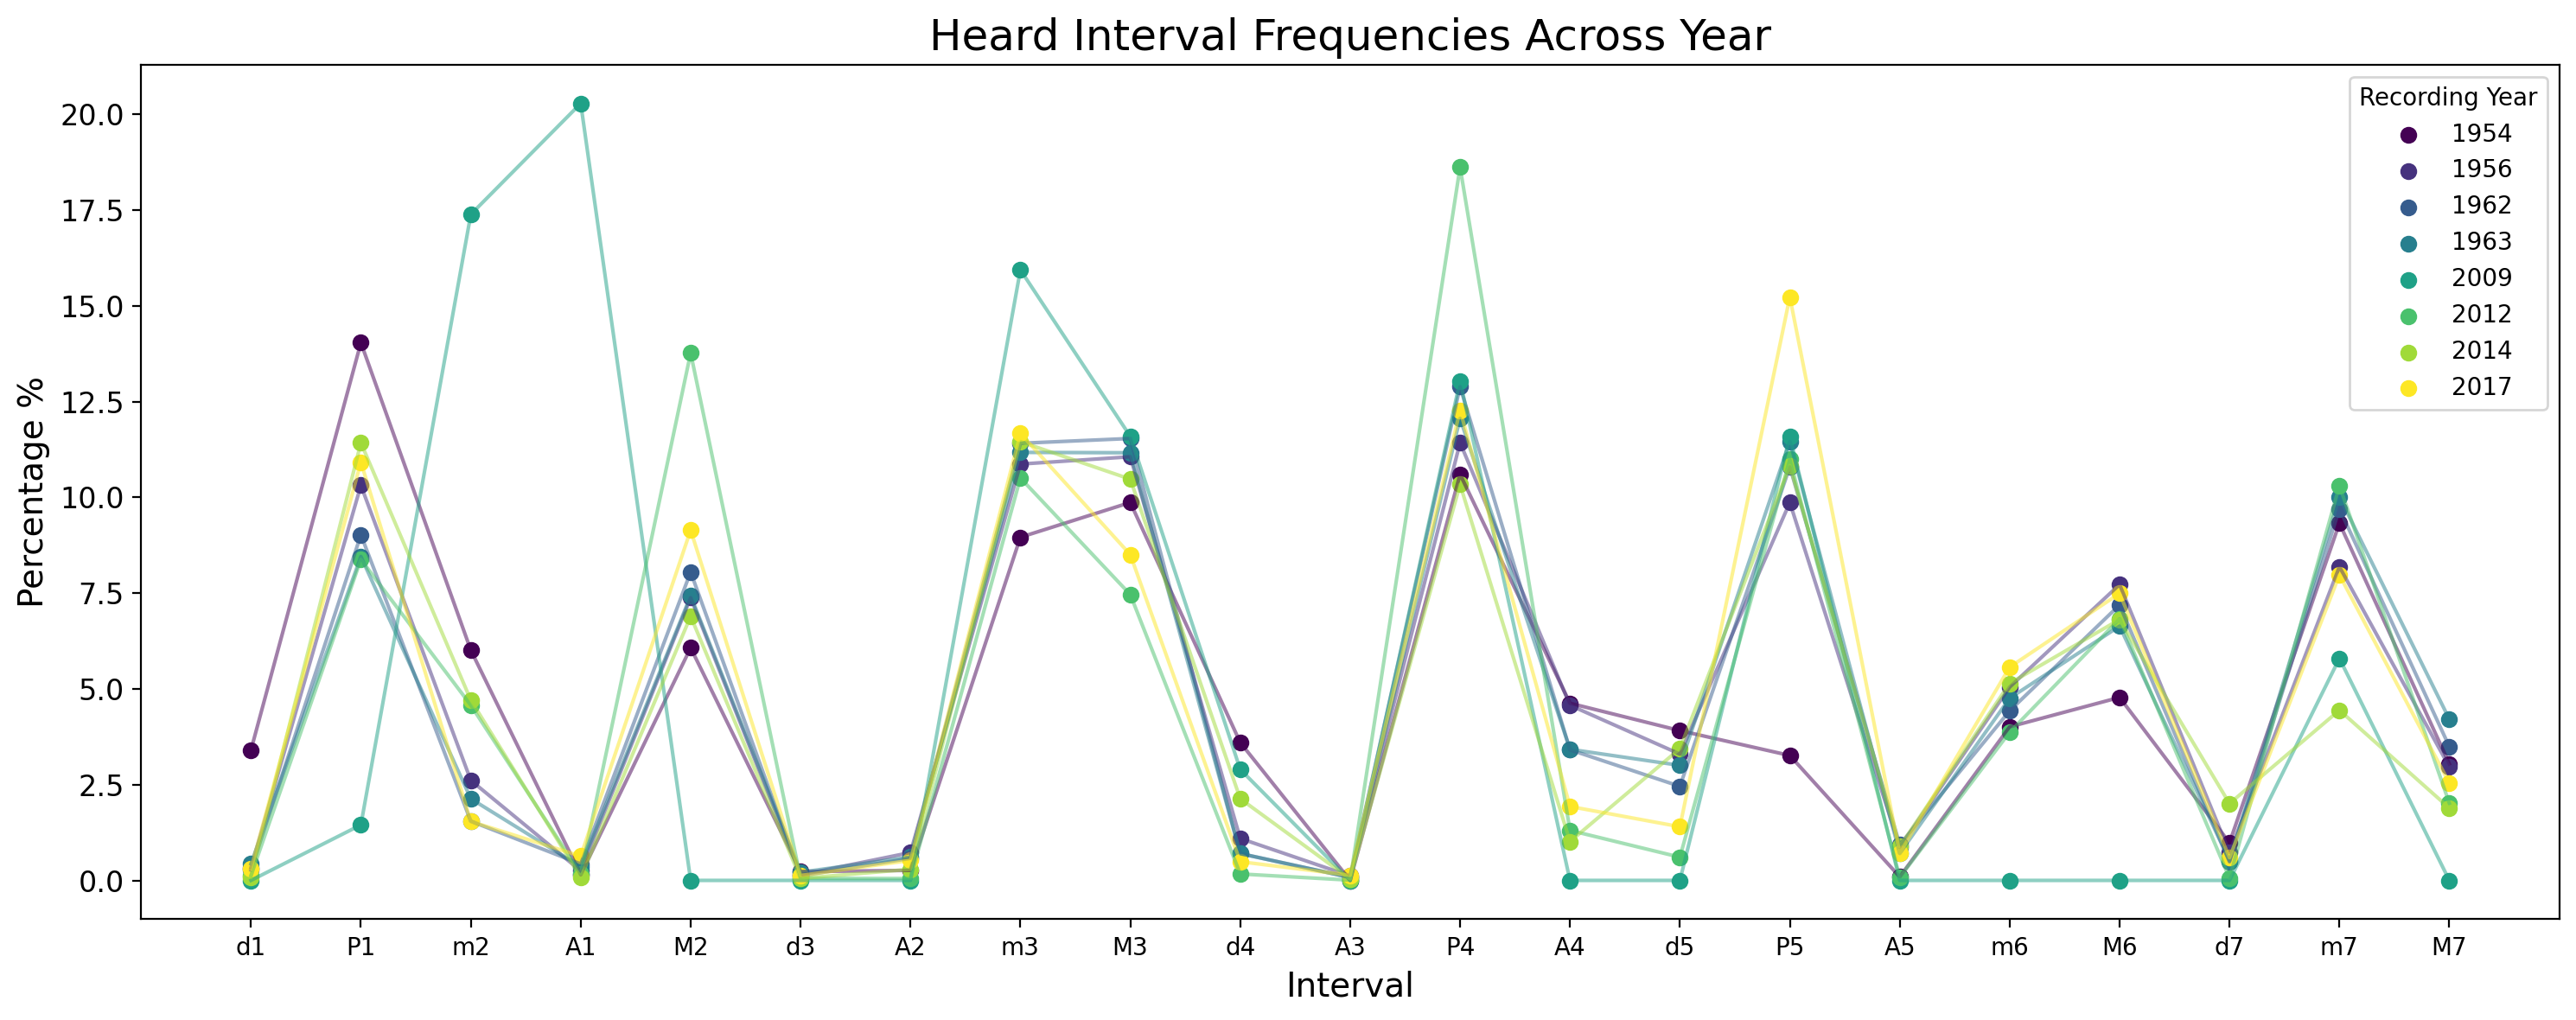

In [203]:
canonical_intervals = [
    'd1', 'P1', 'm2', 'A1', 'M2', 'd3', 'A2', 'm3', 'M3', 'd4', 'A3', 'P4', 'A4', 'd5',
    'P5', 'A5', 'm6', 'M6', 'd7', 'm7', 'M7'
]

interval_order = {
    'd1': -1,
    'P1': 0,
    'm2': 1, 'A1': 1,
    'M2': 2, 'd3': 2,
    'A2': 3, 'm3': 3,
    'M3': 4, 'd4': 4,
    'A3': 5 ,'P4': 5,
    'A4': 6, 'd5': 6,
    'P5': 7,
    'A5': 8, 'm6': 8,  
    'M6': 9, 'd7': 9,
    'm7': 10,
    'M7': 11,
}

baseline_df = pd.DataFrame({
    'interval_name': canonical_intervals,
    'percentage': 0.0
})

keys = list(data.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    # Format title from key (tuple or string)
    if isinstance(key, tuple):
        label = " – ".join(str(k) for k in key)
    else:
        label = str(key)

    interval = data[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Step 3: fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    # Optional: drop the extra '_base' and '_actual' columns if needed
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Year', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_Heard")
plt.show()
